# 1. Thư viện

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, levene
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, QuantileTransformer, OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.metrics import mean_squared_error
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.ensemble import IsolationForest, GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.model_selection import KFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif, RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from itertools import combinations


In [2]:
utils_path = os.path.abspath(os.path.join(os.getcwd(), "../..", "src"))

if utils_path not in sys.path:
    sys.path.append(utils_path)

from utils import *

In [3]:
CSV_PATH = "../../data/Tabular/raw/adult.csv"
CSV_PROCESSED_PATH = "../../data/Tabular/processed/adult.csv"
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

In [4]:
df = pd.read_csv(CSV_PATH)
df.replace("?", pd.NA, inplace=True)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [5]:
labels = df.columns.to_list()

num_cols = df.select_dtypes(include="number").columns.to_list()
cat_cols = df.select_dtypes(include=["object", "category", "str"]).columns.to_list()

print(f"Các dữ liệu số: {num_cols}")
print(f"Các dữ liệu chuỗi: {cat_cols}")

Các dữ liệu số: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Các dữ liệu chuỗi: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']


# 2. Các kỹ thuật tiền xử lý và đánh giá định lượng

## 2.1. Xử lý giá trị thiếu có kiểm soát

### RMSE (Root Mean Squared Error)
Độ đo đánh giá sai lệch giữa giá trị thực và giá trị dữ đoán (điền khuyết).

### Công thức

$$RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^n(y_i - \hat{y_i})^2}$$

Trong đó:

* $y_i$: giá trị thực.
* $\hat{y_i}$: giá trị điền khuyết.
* $n$: số lượng mẫu quan sát.

RMSE càng nhỏ thì độ chính xác càng cao.

In [6]:
def mcar(df: pd.DataFrame, missing_rate=0.1) -> tuple[pd.DataFrame, np.ndarray]:
    df_missing = df.copy()
    mask = np.random.rand(*df.shape) < missing_rate

    df_missing[mask] = np.nan

    return df_missing, mask

def compute_rmse(original: pd.DataFrame, imputed: pd.DataFrame, mask):
    return np.sqrt(mean_squared_error(original[mask], imputed[mask]))

def impute_simple(df: pd.DataFrame, strategy: str) -> pd.DataFrame:
    imputer = SimpleImputer(strategy=strategy)
    return pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

def impute_knn(df: pd.DataFrame, k: int) -> pd.DataFrame:
    imputer = KNNImputer(n_neighbors=k)
    return pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

def impute_mice(df: pd.DataFrame) -> pd.DataFrame:
    imputer = IterativeImputer(random_state=RANDOM_SEED)
    return pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

In [7]:
df_num = df[num_cols].copy()
standard_std = StandardScaler().set_output(transform="pandas")
df_num = standard_std.fit_transform(df_num)
df_missing, mask = mcar(df_num, 0.1)

In [8]:
results = {}

# Mean
imputed = impute_simple(df_missing, "mean")
results["mean"] = compute_rmse(df_num, imputed, mask)

# Median
imputed = impute_simple(df_missing, "median")
results["median"] = compute_rmse(df_num, imputed, mask)

# Mode
imputed = impute_simple(df_missing, "most_frequent")
results["mode"] = compute_rmse(df_num, imputed, mask)

# KNN
for k in [3, 5, 10]:
    imputed = impute_knn(df_missing, k)
    results[f"knn_{k}"] = compute_rmse(df_num, imputed, mask)

# MICE
imputed = impute_mice(df_missing)
results["mice"] = compute_rmse(df_num, imputed, mask)

In [9]:
df_results = pd.DataFrame.from_dict(results, orient="index", columns=["RMSE"])
df_results = df_results.sort_values(by="RMSE")

print("RMSE của từng phương pháp (xếp theo thứ tự giảm dần)")
print(df_results)

RMSE của từng phương pháp (xếp theo thứ tự giảm dần)
            RMSE
mice    0.494517
mean    0.498068
median  0.501669
mode    0.510312
knn_10  0.522764
knn_5   0.561012
knn_3   0.608210


### Đánh giá
* MICE mô hình hoá quan hệ giữa các biến nên tận dụng được cấu trúc của dữ liệu.
* Mean là phương pháp đơn giản nhưng đạt kết quả gần bằng MICE, cho thấy dữ liệu không quá phức tạp.
* Median và Mode đạt kết quả gần bằng Mean, khi quan sát phân phối dữ liệu, nhận thấy giá trị phổ biến óc tần suất cao hơn hẳn các giá trị khác, do đó median và mode thường cho ra cùng một giá trị, phản ánh tính phổ biến của dữ liệu. Riêng "age" có nhiều giá trị có tần suất cao, tạo nên sự khác biệt giữa median và mode.
* Mặc dù KNN thường được kỳ vọng cho kết quả tốt do tận dụng thông tin từ các quan sát lân cận, kết quả thực nghiệm cho thấy phương pháp này hoạt động kém hơn cả phương pháp mode. Nguyên nhân có thể do dữ liệu có mức tương quan thấp giữa các biến, cùng với sự tồn tại của các biến số rời rạc làm giảm ý nghĩa của khoảng cách Euclide trong thuật toán KNN.

**Kết luận:** Sử dụng phương pháp điền khuyết MICE với dữ liệu số.

In [10]:
df_process = df.copy()
df_process[num_cols] = impute_mice(df_process[num_cols])

Với biến phân loại, sử dụng kết quả MAR được khảo sát ở <code>03_EDA_tabular.ipynb</code>như sau:

* "workclass": không phụ thuộc vào 2 biến phân loại còn lại, giả định mô hình rằng "workclass" phụ thuộc vào "education".
* "occupation": phụ thuộc vào "workclass".
* "native.country": phụ thuộc vào "workclass" và "occupation".

In [11]:
df_process["workclass"] = df_process.groupby("education")["workclass"] \
    .transform(lambda x: x.fillna(x.mode()[0]))

df_process["occupation"] = df_process.groupby("workclass")["occupation"] \
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Missing"))

df_process["native.country"] = df_process.groupby(["workclass", "occupation"])["native.country"] \
    .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Missing"))

## 2.2. Phát hiện ngoại lai bằng nhiều kỹ thuật

### IQR

#### Nguyên lý
Giả định dữ liệu tuân theo phân phối chuẩn. Dựa theo nguyên tắc $k \sigma$:

* 68% dữ liệu nằm trong khoảng $\mu \pm 1 \sigma$.
* 95% dữ liệu nằm trong khoảng $\mu \pm 2 \sigma$.
* 99.7% dữ liệu nằm trong khoảng $\mu \pm 3 \sigma$.

![](../../images/boxplot_vs_normalization.png)

Một điểm được xem là ngoại lai nếu không nằm trong $[a, b]$.

#### Công thức
$$IQR = Q_3 - Q_1$$

$$
\begin{cases}
a = Q_1 - 1.5 * IQR \\
b = Q_3 + 1.5 * IQR
\end{cases}
$$
Trong đó:

* $Q_1$: tứ phân vị 25%.
* $Q_3$: tứ phân vị 75%.
* IQR: độ phân tán của 50% dữ liệu trung tâm.

### Z-score

#### Nguyên lý
Đo khoảng cách sau chuẩn hoá z-score dựa trên quy tắc $k \sigma$:

* 68% dữ liệu nằm trong khoảng $\mu \pm 1 \sigma$.
* 95% dữ liệu nằm trong khoảng $\mu \pm 2 \sigma$.
* 99.7% dữ liệu nằm trong khoảng $\mu \pm 3 \sigma$.

![](../../images/normlization.png) 

Các điểm nằm $\mu \pm 3 \sigma$ bên ngoài được xem là ngoại lai.

Do sau chuẩn hoá, $\mu = 0$ và $\sigma = 1$, ta có ngưỡng phát hiện ngoại lai $|z| > 3$

#### Công thức

$$z = \frac{x - \mu}{\sigma}$$

### Isolation Forest

#### Nguyên lý
Các ngoại lai là các điểm nằm lẻ loi, có thể dễ bị cô lập, phân tách. Các điểm bình thường nằm trong vùng dày đặc, cần nhiều lần chia để có thể cô lập chúng.


#### Pipeline
Sử dụng các cây quyết định (decision tree) xây dựng ngẫu nhiên: Chọn ngẫu nhiên một biến, sau đó chọn một giá trị ngẫu nhiên nằm giữa min và max của biến và chia dữ liệu thành 2 nhóm. 

IF giả định rằng các ngoại lai do quá khác biệt, có thể nhanh chóng được phân tách chỉ sau vài lần split ngẫu nhiên đầu tiên. Vì vậy trong một cây, các điểm bất thường sẽ nằm ở các nhánh gần gốc hơn, do cần ít bước phân tách hơn để cô lập chúng hơn. 

$$s(x, n) = 2^{- \frac{E(h(x))}{c(n)}}$$

Trong đó:

* $h(x)$: số bước để cô lập điểm x.
* $E(h(x))$: trung bình trên nhiều cây.
* $c(n)$: hệ số chuẩn hoá.

Ngưỡng phát hiện ngoại lai:

$$s(x, n) > alpha$$

### Local Outlier Factor

#### Nguyên lý
So sánh mật độ của điểm x với các k điểm lân cận. Ngoại lai là điểm có mật độ thấp hơn hẳn so với mật độ của các điểm lân cận.

#### Công thức
$$LRD_k(x) = \frac{1}{\frac{1}{|N_k(x)|}\Sigma_{o \in N_k(x)} max[d(x, o), d_k(o)]}$$

$$LOF_k(x)= \frac{\Sigma_{i \in N_k(x)} \frac{LRD_k(o)}{LRD_k(x)}}{|N_k(x)|}$$

Trong đó:

* $d(x, o)$: khoảng cách giữa x và hàng xóm o.
* $d_k(o)$: khoảng cách từ o đến hàng xóm thứ k của nó.

#### Pipeline với k điểm lân cận

Với mỗi điểm x:
1. Tìm k-nearest neighbors của mỗi điểm

* Xác định tập lân cận:
$$N_k(x)={o_1, o_2, \cdots, o_k}$$
* Tính khoảng cách:
$$d(x, o_1), d(x, o_2), \cdots, d(x, o_k)$$

2. Tính k-distance cho từng hàng xóm

Với mỗi $o \in N_k(x)$:

* Tìm k-nearest neighbors của o: $N_k(o)$
* Xác định:
$$d_k(o) = \text{k-distance của } o$$

3. Tính LRD và LOF của mỗi điểm x

### DBSCAN

#### Nguyên lý
DBSCAN xác định cụm là vùng có mật độ điểm cao, được ngăn cách bởi vùng có mật độ thấp.

* Vùng mật độ cao -> các điểm thuộc cùng một cụm.
* Vùng mật độ thấp -> điểm là biên hoặc nhiễu.

**Tham số:**

* $\epsilon$: xác định bán kính của một lân cận.
* $minPts$: xác định độ dày tối thiểu cùng một lân cận.

Các ngoại lai là điểm mà sau thuật toán DBSCAN mà không thuộc cụm nào và không gần core point (có ít nhất $minPts$ trong bán kính $\epsilon$)

#### Pipeline

1. Chọn một điểm chưa xét.
2. Kiểm tra trong lân cận $\epsilon$.
* Nếu đủ minPts -> core point.
* Ngược lại -> tạm xem là ngoại lai.
3. Mở rộng cụm
* Với mỗi core point:
    * Lấy tất cả điểm trong vùng $\epsilon$.
    * Nếu có điểm nào cũng là core -> tiếp tục mở rộng.

Đối với LOF và DBSCAN, sử dụng RobustScaler như một bước đệm để đảm bảo tính đồng nhất về khoảng cách giữa các biến mà không bị ảnh hưởng bởi chính các giá trị ngoại lai.

In [12]:
# mask nhận giá trị True là ngoại lai, False là điểm bình thường của dữ liệu

def outlier_iqr(df: pd.DataFrame) -> pd.Series:
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    mask = ((df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR))).any(axis=1)
    return mask.values

def outlier_zscore(df, threshold=3) -> pd.Series:
    X = StandardScaler().fit_transform(df)
    z = np.abs(X)
    return (z > threshold).any(axis=1)

def outlier_iforest(df, contamination) -> pd.Series:
    model = IsolationForest(contamination=contamination, random_state=42)
    y = model.fit_predict(df)
    return (y == -1)

def outlier_lof(df, n_neighbors) -> pd.Series:
    X = RobustScaler().fit_transform(df)
    model = LocalOutlierFactor(n_neighbors=n_neighbors)
    y = model.fit_predict(X)
    return (y == -1)

def outlier_dbscan(df, eps=0.5, min_samples=5) -> pd.Series:
    X = RobustScaler().fit_transform(df)
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    return (labels == -1)

def jaccard(a, b):
    inter = np.sum(a & b)
    union = np.sum(a | b)
    return inter / union if union > 0 else 0

def ks_test(original, cleaned):
    p_values = {}
    for col in original.columns:
        stat, p = ks_2samp(original[col], cleaned[col])
        p_values[col] = p
    return p_values

def ks_summary(df, mask, name):
    df_clean = df[~mask]

    ks_result = ks_test(df, df_clean)
    print(name)
    print(ks_result)

In [13]:
df_num = df_process[num_cols].copy()

In [14]:
results = {}

results["IQR"] = outlier_iqr(df_num)
results["Z-score"] = outlier_zscore(df_num)

for c in [0.01, 0.05, 0.1]:
    results[f"IF_{c}"] = outlier_iforest(df_num, c)

for k in [10, 20, 50]:
    results[f"LOF_{k}"] = outlier_lof(df_num, k)

results["DBSCAN"] = outlier_dbscan(df_num)

In [15]:
rates = {}
n = len(df_num)

for name, mask in results.items():
    rates[name] = [np.sum(mask), np.sum(mask) / n]

df_rates = pd.DataFrame.from_dict(rates, orient="index", columns=["Outlier Sample", "Outlier Rate"])
print(df_rates)

         Outlier Sample  Outlier Rate
IQR               13564      0.416572
Z-score            2733      0.083935
IF_0.01             326      0.010012
IF_0.05            1628      0.049998
IF_0.1             3256      0.099997
LOF_10             1667      0.051196
LOF_20             1747      0.053653
LOF_50             1934      0.059396
DBSCAN             4645      0.142655


Tập dữ liệu có các biến số có độ lệch cao: "fnlwgt", "capital.gain", "capital.loss" bị lệch phải rất nghiêm trọng. Đặc biệt "capital.gain"/"capital.loss" có phần lớn giá trị bằng 0. "hours.per.week" tập trung cực lớn tại điểm 40, trong khi "education.num" có các đỉnh rời rạc.

* IQR có tỉ lệ ngoại lai rất cao do dữ liệu lệch mạnh, IQR hoạt động rất kém trên dữ liệu bị lệch. Khi dữ liệu tập trung quá nhiều vào một khoảng hẹp (như "capital.gain" toàn số 0), khoảng $Q3 + 1.5 \times IQR$ sẽ rất nhỏ, khiến hầu hết các giá trị thực tế khác 0 đều bị coi là ngoại lai.
* Z-score giả định dữ liệu gần chuẩn, với các biểu đồ bị lệch nặng như trên, Z-score sẽ bị kéo theo các giá trị cực đại, làm lệch giá trị trung bình và độ lệch chuẩn, không phản ánh chính xác bản chất ngoại lai của các điểm dữ liệu không thuộc phân phối chuẩn.
* Isolation Forest có tỉ lệ ngoại lai gần như chính xác với tham số contamination. Đây là phương pháp loại bỏ nhiễu theo số lượng yêu cầu, do đó cần có giả định ban đầu mà không thể tự định nghĩa ngoại lai là gì.
* Local Outlier Factor có tỉ lệ ngoại lai thấp và ổn định khi tăng n_neighbors cho thấy các ngoại lai là cục bộ, dữ liệu có cấu trúc cục bộ rõ ràng.
* DB-SCAN có tỉ lệ ngoại lai gần Z-score và IF_0.1, có thể chấp nhận được nhưng cần chú ý việc chọn tham số epsilon và minPts.

In [16]:
jac_matrix = pd.DataFrame(index=results.keys(), columns=results.keys())

for k1, k2 in combinations(results.keys(), 2):
    val = jaccard(results[k1], results[k2])
    jac_matrix.loc[k1, k2] = val
    jac_matrix.loc[k2, k1] = val

jac_matrix.replace(np.nan, 1, inplace=True)
print(jac_matrix)

              IQR   Z-score   IF_0.01   IF_0.05    IF_0.1    LOF_10    LOF_20  \
IQR             1  0.201489  0.024034  0.120024  0.239499  0.073967  0.069951   
Z-score  0.201489         1   0.11439  0.449801   0.58607  0.098078   0.10182   
IF_0.01  0.024034   0.11439         1  0.200246  0.100123  0.056734  0.045913   
IF_0.05  0.120024  0.449801  0.200246         1       0.5  0.116949  0.112026   
IF_0.1   0.239499   0.58607  0.100123       0.5         1  0.118101   0.11475   
LOF_10   0.073967  0.098078  0.056734  0.116949  0.118101         1   0.41601   
LOF_20   0.069951   0.10182  0.045913  0.112026   0.11475   0.41601         1   
LOF_50   0.078272  0.141913  0.037649  0.138383  0.158224  0.205557  0.394847   
DBSCAN   0.335852   0.36807  0.064454  0.312892  0.474893  0.144515  0.157971   

           LOF_50    DBSCAN  
IQR      0.078272  0.335852  
Z-score  0.141913   0.36807  
IF_0.01  0.037649  0.064454  
IF_0.05  0.138383  0.312892  
IF_0.1   0.158224  0.474893  
LOF_10   

### IQR và Z-score
IQR và Z-score đều là các phương pháp thống kê đơn biến nhằm xác định các điểm nằm "xa" trung tâm của dữ liệu. Do dữ liệu lệch mạnh:

* Z-score: Sử dụng Trung bình (Mean) và Độ lệch chuẩn (Standard Deviation). Khi dữ liệu bị lệch nặng hoặc có các giá trị cực đại, Mean sẽ bị "kéo" về phía đuôi và Standard Deviation sẽ tăng vọt. Điều này làm cho "thước đo" của Z-score bị giãn ra, dẫn đến việc nó chỉ bắt được những điểm cực kỳ xa ở tận cùng của đuôi.
* IQR: Sử dụng Trung vị (Median) và các phân vị (Quartiles). Những chỉ số này rất "bền vững" (robust) - chúng không bị ảnh hưởng bởi các giá trị cực đoan.
Hệ quả là trên biểu đồ, IQR sẽ đặt "vạch kẻ đường" sớm hơn rất nhiều so với Z-score. Như bảng thống kê trước, IQR bắt tới 41% dữ liệu là ngoại lai, trong khi Z-score chỉ bắt 8%.

### Z-score và IF_0.1
Đạt 0.586, mức trùng lặp cao nhất trong bảng, cho thấy Isolation Forest (khi đặt ngưỡng 10%) và Z-score có xu hướng đồng thuận cao về việc cái gì là "xa lạ" về mặt tổng thể (Global Outliers).

### LOF và các phương pháp còn lại
Các chỉ số của LOF đối với IQR hay Z-score đều rất thấp (~0.04-0.06). Điều này khẳng định LOF đang tìm các ngoại lai cục bộ (những điểm đứng lẻ loi so với hàng xóm của chúng), trong khi IQR/Z-score tìm ngoại lai toàn cục (xa trung tâm dữ liệu).

### DBSCAN và các phương pháp còn lại
Độ trùng lặp với IF_0.1 đạt 0.503, do cả hai đều có xu hướng tìm kiếm các điểm nằm trong vùng "không gian trống" hoặc vùng mật độ thấp. Điều này cho thấy các điểm ngoại lai mà DBSCAN tìm được mang tính chất ngoại lai toàn cục.

Độ trùng lặp với LOF thấp (~0.07-0.11) dù đều dựa trên nguyên lý mật độ, do:

* DBSCAN sử dụng một thước đo mật độ cố định trên toàn bộ không gian dữ liệu (thông qua tham số eps). Nếu vùng nào thưa hơn ngưỡng này, nó coi là ngoại lai.
* LOF so sánh mật độ của một điểm với mật độ của các láng giềng xung quanh nó.
Hệ quả là trong dữ liệu có những cột như "education.num" với các đỉnh mật độ khác nhau. DBSCAN có thể coi toàn bộ một cụm thưa là ngoại lai, trong khi LOF sẽ đi sâu vào từng cụm để tìm ngoại lai bên trong cụm đó.

Độ trùng lặp với Z-score cao gấp đôi so với IQR, củng cố thêm nhận định rằng DBSCAN đang bắt các điểm ở "đuôi" của phân phối (giống Z-score) nhưng thông minh hơn một chút vì không bị ép buộc vào giả định phân phối chuẩn. DBSCAN loại bỏ các điểm ở vùng thưa thớt mà Z-score có thể bỏ sót do bị lệch trung bình.

### Kiểm định KS

Xác định hai tập dữ liệu có cùng phân phối hay không. Mục đích để kiểm tra sau khi đã loại bỏ ngoại lai, dữ liệu có bị lệch khỏi phân phối ban đầu hay không.

Với mức ý nghĩa alpha = 0.05:

* Giả thuyết H0: Hai phân phối giống nhau.
* Giả thuyết H1: Hai phân phối không giống nhau.
* p_value <= alpha: Bác bỏ giả thuyết H0, nghĩa là hai phân phối khác nhau, phương pháp loại bỏ ngoại lai này làm biến đổi đáng kể cấu trúc dữ liệu.
* p_value > alpha: Chấp nhận giả thuyết H0, nghĩa là hai phân phối giống nhau, phương pháp loại bỏ ngoại lai này không làm biến đổi cấu trúc dữ liệu.

In [17]:
ks_summary(df_num, results["IQR"], "IQR")
ks_summary(df_num, results["Z-score"], "Z-score")
ks_summary(df_num, results["IF_0.01"], "IF_0.01")
ks_summary(df_num, results["IF_0.05"], "IF_0.05")
ks_summary(df_num, results["IF_0.1"], "IF_0.1")
ks_summary(df_num, results["LOF_10"], "LOF_10")
ks_summary(df_num, results["LOF_20"], "LOF_20")
ks_summary(df_num, results["LOF_50"], "LOF_50")
ks_summary(df_num, results["DBSCAN"], "DBSCAN")

IQR
{'age': np.float64(1.2234654503354142e-13), 'fnlwgt': np.float64(3.210013629529954e-10), 'education.num': np.float64(3.677307062007556e-18), 'capital.gain': np.float64(7.543558046843516e-73), 'capital.loss': np.float64(3.970399731364069e-23), 'hours.per.week': np.float64(1.8743914348092278e-301)}
Z-score
{'age': np.float64(0.04887336332652714), 'fnlwgt': np.float64(0.05784965562225175), 'education.num': np.float64(0.13321026326363783), 'capital.gain': np.float64(0.49954850110400306), 'capital.loss': np.float64(5.213955294793708e-28), 'hours.per.week': np.float64(0.004977581103062787)}
IF_0.01
{'age': np.float64(0.9881746352823103), 'fnlwgt': np.float64(1.0), 'education.num': np.float64(0.9665878975317272), 'capital.gain': np.float64(0.6710432520446843), 'capital.loss': np.float64(0.9861303098243934), 'hours.per.week': np.float64(0.9664211283228844)}
IF_0.05
{'age': np.float64(0.025947928081979987), 'fnlwgt': np.float64(0.7793438112007798), 'education.num': np.float64(0.018886973351

### Đánh giá
* Nhóm biến đổi cấu trúc:
    * IQR: Phương pháp tác động tiêu cực nhất. p_value của tất cả các biến đều bằng 0. Do việc xoá bỏ 41% dữ liệu đã làm biến dạng hoàn toàn dữ liệu.
    * DBSCAN: Các giá trị p_value đều thấp, DBSCAN thay đổi đáng kể phân phối của tất cả các biến. Điều này xảy ra vì DBSCAN loại bỏ các điểm dựa trên mật độ không gian, vô tình xóa đi các mảng dữ liệu quan trọng trong các biến đơn lẻ.

* Nhóm bảo toàn cấu trúc:
    * IF_0.01: Các giá trị p_value đều rất cao (~0.67-1). Với tỉ lệ ngoại lai 1%, IF_0.1 chỉ loại bỏ những điểm cực kỳ xa mà không làm ảnh hưởng đến hình dáng phân phối chung.
    * LOF: Hầu hết các biến ("age", "fnlwgt", "capital.loss") đều có p_value xấp xỉ 1.0 (không thay đổi). Riêng biến "capital.gain" có p_value khá thấp (~0.01-0.04), tức là đã có sự thay đổi. Vì capital.gain có quá nhiều giá trị 0, bất kỳ giá trị khác 0 nào đứng lẻ loi đều bị LOF coi là ngoại lai và xóa đi, dẫn đến thay đổi phân phối đặc thù của biến này.

* Nhóm cân bằng:
    * Z-score: bảo toàn tốt "capital.gain" p_value = 0.5 nhưng lại phá hủy cấu trúc của "capital.loss". Z-score hoạt động không ổn định trên bộ dữ liệu này do các biến có đặc tính phân phối khác nhau.
    * IF_0.05: thay đổi hầu hết các biến (trừ "fnlwgt"). Ở mức 5%, Isolation Forest bắt đầu can thiệp sâu vào cấu trúc dữ liệu. Đây là giới hạn tối đa có thể chấp nhận được trước khi làm mất đi thông tin quan trọng.

**Kết luận:** Lựa chọn phương pháp xử lý ngoại lai IF_0.01 với dữ liệu số.

In [18]:
df_process = df_process[~results["IF_0.01"]]

## 2.3. Chuẩn hoá dữ liệu có kiểm định

#### Mục tiêu
Do các biến có thang đo khác nhau, nếu dùng trực tiếp dữ liệu thô, biến lớn sẽ áp đảo biến nhỏ hơn.

Trong các phương pháp phân cụm như: k-means và k-nearest neighbors, khoảng cách Euclide thường được sử dụng, nếu không chuẩn hoá, biến có scale lớn sẽ chi phối khoảng cách, đóng góp của biến nhỏ trở nên không đáng kể dẫn đến mô hình học sai bản chất dữ liệu.

Sau chuẩn hoá, mỗi biến đóng góp tương đương, không xảy ra hiện tượng sai lệch (bias) theo đơn vị đo.

| Phương pháp | Mục tiêu | Biến đổi | Yêu cầu dữ liệu | Hạn chế |
| --- | --- | --- | --- | --- |
| Min-Max Scaling | Đưa dữ liệu về khoảng [0, 1] | $x' = \frac{x - x_{min}}{x_{max} - x_{min}}$ | Dữ liệu đã sạch, cần giữ quan hệ tương đối | Rất nhạy với outlier |
| Z-score | Đưa dữ liệu về mean = 0, std = 1 | $x' = \frac{x - \mu}{\sigma}$ | Dữ liệu gần phân phối chuẩn | Nhạy với outlier |
| Robust Scaling | Giảm ảnh hưởng của outlier | $x' = \frac{x - Q_1}{Q_3 - Q_1}$ | Dữ liệu có outlier, phân phối bị lệch | Phụ thuộc vào IQR (hiệu quả kém khi lệch mạnh)|
| Quantile Transform Uniform | Đưa dữ liệu về phân phối đều $\mathcal{U}(0,1)$ | $x' \sim \mathcal{U}(0, 1)$ | Dữ liệu rất lệch, muốn loại bỏ phân phối gốc | Mất thông tin khoảng cách |
| Quantile Transform Normal | Đưa dữ liệu về phân phối chuẩn $\mathcal{N}(0,1)$ | $x' \sim \mathcal{N}(0, 1)$ | Giả định dữ liệu Gaussian | Mất thông tin khoảng cách, thay đổi phân phối |

In [19]:
# Min-Max
minmax = MinMaxScaler().set_output(transform="pandas")
X_minmax = minmax.fit_transform(df_process[num_cols])

# Z-score
zscore = StandardScaler().set_output(transform="pandas")
X_zscore = zscore.fit_transform(df_process[num_cols])

# Robust
robust = RobustScaler().set_output(transform="pandas")
X_robust = robust.fit_transform(df_process[num_cols])

# Quantile - Uniform
qt_uniform = QuantileTransformer(output_distribution='uniform').set_output(transform="pandas")
X_qt_uniform = qt_uniform.fit_transform(df_process[num_cols])

# Quantile - Normal
qt_normal = QuantileTransformer(output_distribution='normal').set_output(transform="pandas")
X_qt_normal = qt_normal.fit_transform(df_process[num_cols])

### Kiểm định Levene

Kiểm tra các nhóm dữ liệu có cùng phương sai hay không.

Với mức ý nghĩa alpha = 0.05:

* Giả thuyết H0: Các nhóm có cùng phương sai (homoscedasticity)
* Giả thuyết H1: Có ít nhất một nhóm khác phương sai.
* p <= alpha: Bác bỏ giả thuyết H0, nghĩa là có ít nhất một nhóm khác phương sai.
* p > alpha: Chấp nhận giả thuyết H0, nghĩa là các nhóm có cùng phương sai.

In [20]:
def levene_test_by_class(df, target, col):
    labels = df[target].unique()
    groups = [df[df[target] == c][col] for c in labels]
    stat, p = levene(*groups)
    return stat, p

def levene_summary(df, target):
    num_cols = df.select_dtypes(include=['number']).columns
    test_cols = [c for c in num_cols if c != target]

    print(f"{'Biến':<20} | {'p-value':<12} | {'Kết luận'}")
    print("-" * 60)

    for col in test_cols:
        stat, p = levene_test_by_class(df, target, col)

        result = f"Bác bỏ giả thuyết H0, có ít nhất một nhóm khác phương sai." if p <= 0.05 else f"Chấp nhận giả thuyết H0, các nhóm có cùng phương sai."

        print(f"{col:<20} | {p:<12.4e} | {result}")

In [21]:
X_minmax["income"] = df_process["income"]
X_zscore["income"] = df_process["income"]
X_robust["income"] = df_process["income"]
X_qt_uniform["income"] = df_process["income"]
X_qt_normal["income"] = df_process["income"]

print("\nMin Max")
levene_summary(X_minmax, "income")
print("\nZ score")
levene_summary(X_zscore, "income")
print("\nRobusts Scaling")
levene_summary(X_robust, "income")
print("\nQuantile Transform Uniform")
levene_summary(X_qt_uniform, "income")
print("\nQuantile Transform Normal")
levene_summary(X_qt_normal, "income")


Min Max
Biến                 | p-value      | Kết luận
------------------------------------------------------------
age                  | 1.2534e-159  | Bác bỏ giả thuyết H0, có ít nhất một nhóm khác phương sai.
fnlwgt               | 6.2490e-05   | Bác bỏ giả thuyết H0, có ít nhất một nhóm khác phương sai.
education.num        | 8.1002e-59   | Bác bỏ giả thuyết H0, có ít nhất một nhóm khác phương sai.
capital.gain         | 0.0000e+00   | Bác bỏ giả thuyết H0, có ít nhất một nhóm khác phương sai.
capital.loss         | 1.1123e-151  | Bác bỏ giả thuyết H0, có ít nhất một nhóm khác phương sai.
hours.per.week       | 6.7248e-01   | Chấp nhận giả thuyết H0, các nhóm có cùng phương sai.

Z score
Biến                 | p-value      | Kết luận
------------------------------------------------------------
age                  | 1.2534e-159  | Bác bỏ giả thuyết H0, có ít nhất một nhóm khác phương sai.
fnlwgt               | 6.2490e-05   | Bác bỏ giả thuyết H0, có ít nhất một nhóm khác phương 

#### Đánh giá

Do kích thước mẫu lớn, kiểm định Levene cho giá trị các p_value rất nhạy, khiến cho hầu hết đều bác bỏ giả thuyết H0.

p_value của Min Max, Z score, Robust giống nhau hoàn toàn vì kiểm định Levene dựa trên độ lệch tuyệt đối so với Trung vị. Khi ta thực hiện các phép biến đổi tuyến tính, tỷ lệ giữa các độ lệch này không thay đổi. Đối với kiểm định phương sai, Min Max, Z-score hay Robust không làm thay đổi tính đồng nhất phương sai của dữ liệu.

Quantile Uniform ép dữ liệu về phân phối đều. p_value của "hours.per.week" giảm mạnh xuống $10^{-27}$ (từ trạng thái đồng nhất trở thành không đồng nhất). Điều này cho thấy việc "ép" một biến tập trung quá nhiều tại một điểm (như làm 40h/tuần) vào phân phối đều đã làm hỏng tính đồng nhất phương sai giữa các nhóm.

Quantile Normal: Cố gắng đưa dữ liệu về hình chuông. Kết quả p_value của các biến vẫn cực nhỏ.

| Biến | Nhận xét |
| --- | --- |
| age, fnlwgt, education.num | Phương sai của nhóm giàu và nhóm nghèo rất khác nhau |
| capital.gain | p = 0 cho thấy sự chênh lệch cực lớn. Nhóm $>50K$ có biến động thu nhập đầu tư rất lớn, trong khi nhóm $\le 50K$ hầu hết bằng 0 |
| hours.per.week | Độ biến động giờ làm việc giữa người giàu và người nghèo khá tương đồng. |

**Kết luận:** Không có phương pháp scaling nào ở trên thực sự ổn với dữ liệu này hoàn toàn. Tuy nhiên, các phương pháp tuyến tính (Min-Max, Z-score, Robust) giữ được biến hours.per.week ổn định nhất. Quyết định lựa chọn Robust Scaling.

In [22]:
df_process[num_cols] = RobustScaler().fit_transform(df_process[num_cols])

### Biểu đồ Violin

In [23]:
def plot_violin(df, title):
    plt.figure(figsize=(10, 5))
    sns.violinplot(data=df)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()

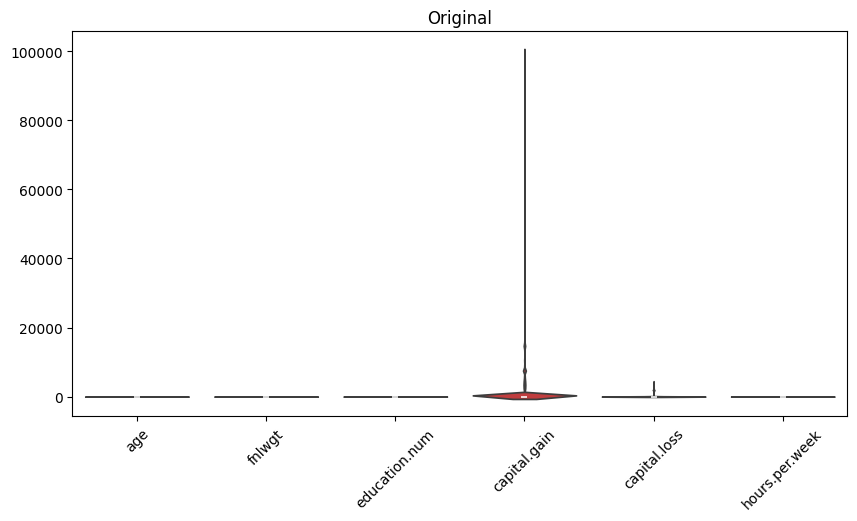

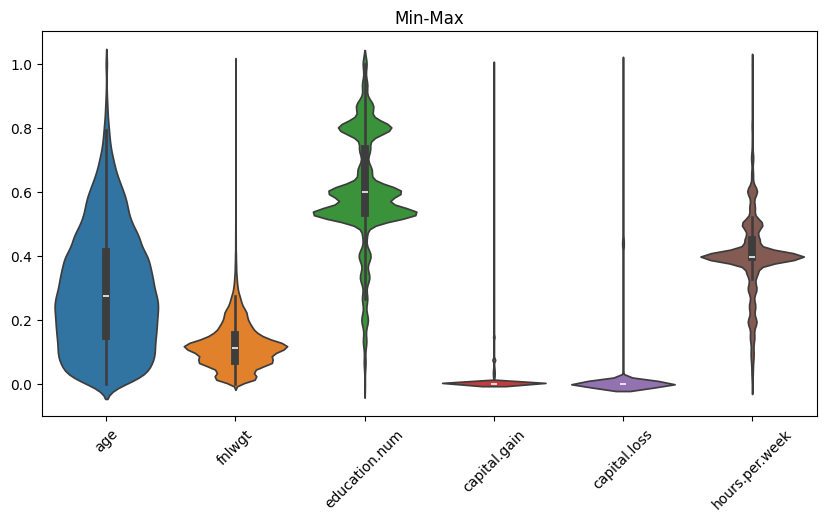

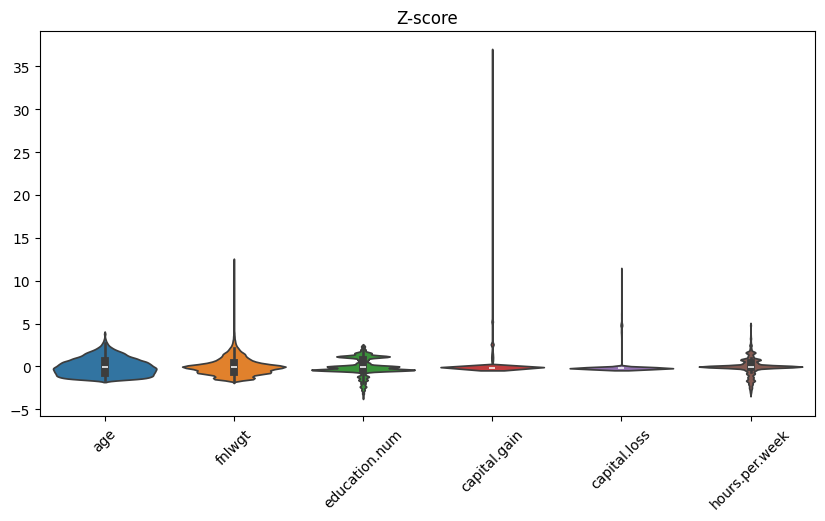

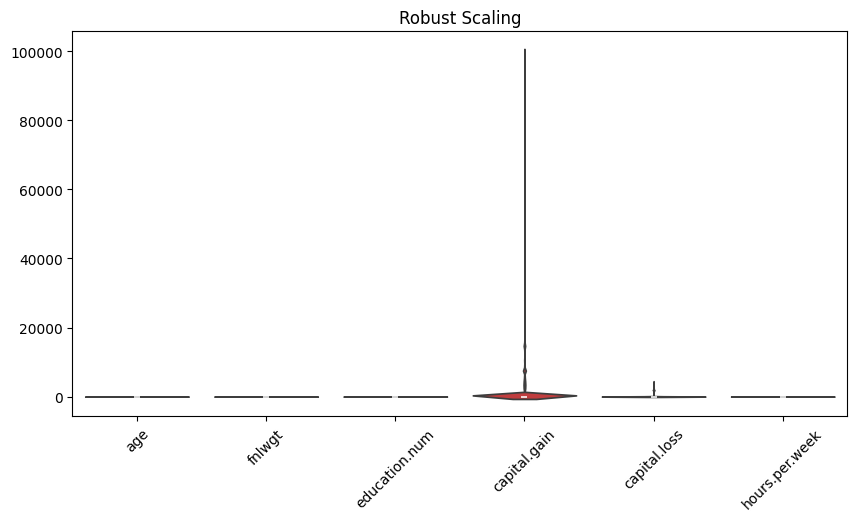

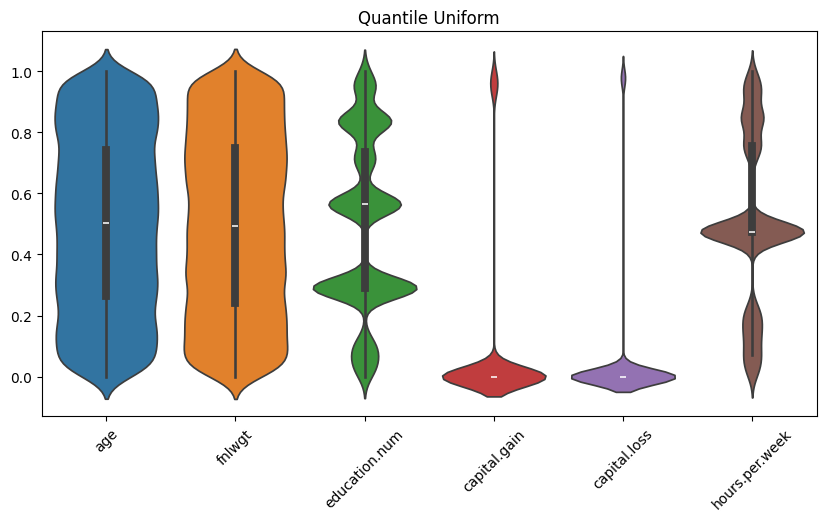

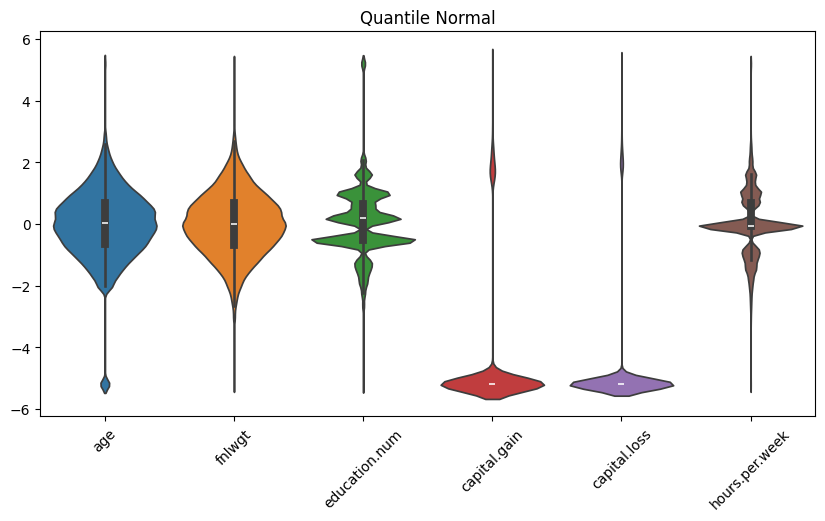

In [24]:
plot_violin(df_process[num_cols], "Original")
plot_violin(X_minmax, "Min-Max")
plot_violin(X_zscore, "Z-score")
plot_violin(X_robust, "Robust Scaling")
plot_violin(X_qt_uniform, "Quantile Uniform")
plot_violin(X_qt_normal, "Quantile Normal")

**Min Max**

"capital.gain" khi bị ép về [0, 1] tạo ra đuôi chiếm trọn toàn bộ không gian, đẩy phần lớn dữ liệu về 0.

**Z score**

Đưa dữ liệu về trung tâm nhưng "capital.gain" có những điểm dữ liệu cách xa trung bình tới 35 lần độ lệch chuẩn.

**Robust**

Biểu đồ này trông khá giống Original nhưng ở một thang đo khác. Vì "capital.gain" có IQR rất nhỏ (do quá nhiều số 0), nên khi chia cho một số nhỏ, các giá trị ngoại lai bị "phóng đại" lên cực lớn.

**Quantile Transform**

Biến tất cả thành hình "khối" (với Uniform) và hình "chuông" (với Normal). "capital.gain" vốn dĩ có rất nhiều giá trị 0 cũng bị kéo giãn ra để lấp đầy khoảng $[0, 1]$ và khoảng phân phối chuẩn.

**Về hình dáng:** Min-Max, Z-score và Robust Scaling giữ nguyên hình dáng phân phối gốc.

**Về xử lý ngoại lai:** Quantile Transform triệt tiêu ảnh hưởng của ngoại lai bằng cách đưa chúng về các phân vị.

## 2.4. Mã hoá biến phân loại nâng cao

Máy học và hầu hết thuật toán thống kê không hiểu trực tiếp dữ liệu dạng chữ (categorical). Vì vậy, mã hoá biến phân loại là bước bắt buộc để biến thông tin định tính thành dạng số mà mô hình có thể xử lý đúng cách.

In [25]:
df_cat = df_process[cat_cols]
df_cat.nunique()

workclass          8
education         16
marital.status     7
occupation        15
relationship       6
race               5
sex                2
native.country    41
income             2
dtype: int64

| Phương pháp | Nguyên lý | Trường hợp sử dụng | Ưu điểm | Hạn chế |
| --- | --- | --- | --- | --- |
| One hot | Mỗi category là một cột nhị phân | Số category ít | Không tạo thứ tự giả | Bùng nổ số chiều khi nhiều giá trị |
| Ordinal | Gán số cho category theo thứ tự | Biến có thứ tự tự nhiên | Đơn giản | Tạo thứ tự giả nếu dữ liệu không có thứ tự |
| Target | Mỗi category là trung bình của target | Category nhiều | Hiệu quả với high-cardinality | Dễ bị leakage dữ liệu từ target |
| Binary | Biểu diễn category bằng số nhị phân | Cân bằng số chiều mã hoá và thông tin | Ít cột hơn one hot và ít thứ tự giả hơn ordinal | Khó hiểu hơn |
| Frequency | Biểu diễn category bằng tần suất xuất hiện | Cần mã hoá nhanh | Đơn giản | Có thể trùng tần suất đối với các category khác nhau |

In [26]:
def target_encode(X, y, n_splits=5) -> pd.DataFrame:    
    global_mean = y.mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    splits = list(kf.split(X))  # compute once, reuse for every column

    result = X.copy()

    for col in X.columns:
        encoded = pd.Series(index=X.index, dtype=float)

        for train_idx, val_idx in splits:
            y_train = y.iloc[train_idx]
            col_train = X[col].iloc[train_idx]
            col_val = X[col].iloc[val_idx]

            means = y_train.groupby(col_train).mean()
            encoded.iloc[val_idx] = col_val.map(means)

        result[col] = encoded.fillna(global_mean)

    return result

def binary_encode(X) -> pd.DataFrame:
    cols = X.columns

    result = X.drop(columns=cols)

    for col in cols:
        
        categories = X[col].dropna().unique()
        ordinal_map = {cat: i for i, cat in enumerate(sorted(categories.astype(str)))}
        ordinal = X[col].map(ordinal_map)

        n_bits = max(int(np.ceil(np.log2(len(categories) + 1))), 1)

        bit_cols = {
            f"{col}_bit{bit}": (ordinal.fillna(0).to_numpy(dtype=int) >> bit) & 1
            for bit in range(n_bits)
        }

        nan_mask = X[col].isna()
        bit_df = pd.DataFrame(bit_cols, index=X.index).astype(float)
        bit_df[nan_mask] = np.nan

        result = pd.concat([result, bit_df], axis=1)

    return result

def frequency_encode(X) -> pd.DataFrame:
    cols = X.columns

    result = X.copy()

    for col in cols:
        freq = result[col].value_counts(normalize=True)
        result[col] = X[col].map(freq)

    return result

In [27]:
X = df_cat.drop(labels=["income"], axis=1)
y = df_process["income"]

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore").set_output(transform="pandas")
X_onehot = encoder.fit_transform(X.drop(columns=["native.country"]))

encoder = OrdinalEncoder().set_output(transform="pandas")
X_ordinal = encoder.fit_transform(X)

encoder = TargetEncoder().set_output(transform="pandas")
X_target = encoder.fit_transform(X, y)

X_binary = binary_encode(X)

X_frequency = frequency_encode(X)


### Phương sai giải thích (Variance Inflation Factor)

Đo mức độ một biến có thể được giải thích bởi các biến còn lại.

$$VIF_i = \frac{1}{1 - R_i^2}$$
Trong đó:
* $R_i^2$: hệ số xác định khi hồi quy biến i theo các biến khác.

| VIF | Ý nghĩa |
| --- | --- |
| $\approx$ 1 | Không cộng tuyến |
| 1-5 | Nhẹ |
| > 5 | Đáng chú ý |
| > 10 | Nghiêm trọng |

In [28]:
def compute_vif(
    X: pd.DataFrame,
    columns: list[str] | None = None,
    threshold: float | None = 5.0,
) -> pd.DataFrame:
    """
    Compute VIF for numeric columns, with automatic handling of:
      - Singular / rank-deficient matrices (one-hot, binary encoding)
      - Near-zero variance columns
      - Perfectly correlated column pairs
    """
    cols = columns or X.select_dtypes(include=np.number).columns.tolist()
    if not cols:
        raise ValueError("No numeric columns found.")

    data = X[cols].dropna()

    # ── 1. Drop zero-variance columns (constants add nothing, break the matrix)
    variance = data.var()
    zero_var = variance[variance == 0].index.tolist()
    if zero_var:
        print(f"Dropping zero-variance columns: {zero_var}")
        cols = [c for c in cols if c not in zero_var]
        data = data[cols]

    # ── 2. Drop perfectly correlated duplicates (|r| == 1)
    corr = data.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    perfect = [col for col in upper.columns if any(upper[col] == 1.0)]
    if perfect:
        print(f"Dropping perfectly correlated columns: {perfect}")
        cols = [c for c in cols if c not in perfect]
        data = data[cols]

    if len(cols) < 2:
        raise ValueError("Fewer than 2 columns remain after cleanup.")

    # ── 3. Compute VIF, replacing inf/nan with a sentinel for readability
    vif_scores = []
    for i in range(len(cols)):
        try:
            v = variance_inflation_factor(data.values, i)
        except Exception:
            v = np.nan
        vif_scores.append(v if np.isfinite(v) else np.nan)

    result = pd.DataFrame({
        "feature": cols,
        "vif":     np.round(vif_scores, 4),
        "flagged": [
            (v >= threshold) if (threshold and not np.isnan(v)) else False
            for v in vif_scores
        ],
    }).sort_values("vif", ascending=False, na_position="first").reset_index(drop=True)

    return result

In [29]:
vif_onehot = compute_vif(X_onehot)
vif_ordinal = compute_vif(X_ordinal)
vif_target = compute_vif(X_target)
vif_binary = compute_vif(X_binary)
vif_frequency = compute_vif(X_frequency)

Dropping perfectly correlated columns: ['occupation_Missing']


/home/chungdat/HCMUS/2025-2026_HK2/Data Mining and Applications/Data_Mining/Lab_1/.venv/lib/python3.12/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping zero-variance columns: ['workclass_bit3', 'education_bit4', 'sex_bit1']


In [30]:
vif_onehot

,feature,vif,flagged
0,workclass_Federal-gov,NaN,False
1,workclass_Local-gov,NaN,False
2,workclass_Never-worked,NaN,False
3,workclass_Private,NaN,False
4,workclass_Self-emp-inc,NaN,False
5,workclass_Self-emp-not-inc,NaN,False
6,workclass_State-gov,NaN,False
7,workclass_Without-pay,NaN,False
8,education_10th,NaN,False
9,education_11th,NaN,False


In [31]:
vif_ordinal

,feature,vif,flagged
0,native.country,23.2022,True
1,race,16.5805,True
2,workclass,8.0759,True
3,education,7.5226,True
4,sex,4.2455,False
5,marital.status,3.9453,False
6,occupation,2.8541,False
7,relationship,2.6130,False


In [32]:
vif_target

,feature,vif,flagged
0,marital.status,45.7200,True
1,relationship,45.1846,True
2,race,22.1892,True
3,native.country,21.7817,True
4,workclass,11.9337,True
5,sex,8.9539,True
6,occupation,5.1479,True
7,education,4.7590,False


In [33]:
vif_binary

,feature,vif,flagged
0,native.country_bit5,52.8196,True
1,native.country_bit1,45.5239,True
2,race_bit2,38.1358,True
3,native.country_bit2,37.7046,True
4,workclass_bit0,13.1026,True
5,education_bit3,7.1807,True
6,workclass_bit1,7.0163,True
7,education_bit0,6.5636,True
8,sex_bit0,5.1601,True
9,race_bit1,4.9289,False


In [34]:
vif_frequency

,feature,vif,flagged
0,sex,17.3903,True
1,relationship,10.0762,True
2,native.country,10.0545,True
3,marital.status,9.7377,True
4,race,8.0713,True
5,occupation,5.9421,True
6,workclass,4.3249,False
7,education,3.6432,False


**Kết luận:**

* sex, income: label incoding
* race, relationship, marital.status, workclass: one hot encoding
* education: ordinal encoding thủ công
* occupation: target encoding
* native.country: frequency encoding

In [35]:
df_process

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
2,1.526316,Private,0.064506,Some-college,0.000000,Widowed,Craft-repair,Unmarried,Black,Female,0.0,4356.0,0.0,United-States,<=50K
3,0.894737,Private,-0.319454,7th-8th,-2.000000,Divorced,Machine-op-inspct,Unmarried,White,Female,0.0,3900.0,0.0,United-States,<=50K
4,0.210526,Private,0.724871,Some-college,0.000000,Separated,Prof-specialty,Own-child,White,Female,0.0,3900.0,0.0,United-States,<=50K
5,-0.157895,Private,0.323294,HS-grad,-0.333333,Divorced,Other-service,Unmarried,White,Female,0.0,3770.0,1.0,United-States,<=50K
6,0.052632,Private,-0.233407,10th,-1.333333,Separated,Adm-clerical,Unmarried,White,Male,0.0,3770.0,0.0,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,-0.789474,Private,1.107042,Some-college,0.000000,Never-married,Protective-serv,Not-in-family,White,Male,0.0,0.0,0.0,United-States,<=50K
32557,-0.526316,Private,0.663029,Assoc-acdm,0.666667,Married-civ-spouse,Tech-support,Wife,White,Female,0.0,0.0,-0.4,United-States,<=50K
32558,0.157895,Private,-0.201709,HS-grad,-0.333333,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,0.0,United-States,>50K
32559,1.105263,Private,-0.222410,HS-grad,-0.333333,Widowed,Adm-clerical,Unmarried,White,Female,0.0,0.0,0.0,United-States,<=50K


In [37]:
cat_cols = set(cat_cols)

mapping = {"Female": 0, "Male": 1}
df_process["sex"] = df_process["sex"].map(mapping)

mapping = {"<=50K": 0, ">50K": 1}
df_process["income"] = df_process["income"].map(mapping)

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore").set_output(transform="pandas")

race_encoded = encoder.fit_transform(df_process[["race"]])
df_process = pd.concat([df_process.drop(columns=["race"]), race_encoded], axis=1)
cat_cols.remove("race")
cat_cols.update(list(race_encoded.columns))

relationship_encoded = encoder.fit_transform(df_process[["relationship"]])
df_process = pd.concat([df_process.drop(columns=["relationship"]), relationship_encoded], axis=1)
cat_cols.remove("relationship")
cat_cols.update(list(relationship_encoded.columns))

marital_encoded = encoder.fit_transform(df_process[["marital.status"]])
df_process = pd.concat([df_process.drop(columns=["marital.status"]), marital_encoded], axis=1)
cat_cols.remove("marital.status")
cat_cols.update(list(marital_encoded.columns))

workclass_encoded = encoder.fit_transform(df_process[["workclass"]])
df_process = pd.concat([df_process.drop(columns=["workclass"]), workclass_encoded], axis=1)
cat_cols.remove("workclass")
cat_cols.update(list(workclass_encoded.columns))

mapping = {"Preschool": 0, "1st-4th": 1, "5th-6th": 2, "7th-8th": 3,
           "9th": 4, "10th": 5, "11th": 6, "12th": 7, "HS-grad": 8,
           "Some-college": 9, "Assoc-voc": 10, "Assoc-acdm": 11,
           "Bachelors": 12, "Masters": 13, "Prof-school": 14, "Doctorate": 15}
df_process["education"] = df_process["education"].map(mapping)

occupation_encoded = target_encode(df_process[["occupation"]], df_process["income"])
df_process = pd.concat([df_process.drop(columns=["occupation"]), occupation_encoded], axis=1)
cat_cols.remove("occupation")
cat_cols.update(list(occupation_encoded.columns))

native_country_encoded = frequency_encode(df_process[["native.country"]])
df_process = pd.concat([df_process.drop(columns=["native.country"]), native_country_encoded], axis=1)
cat_cols.remove("native.country")
cat_cols.update(list(native_country_encoded.columns))

cat_cols = list(cat_cols)

## 2.5. Lựa chọn và giảm chiều đặc trưng

In [65]:
scores_mean = {}
scores_std = {}

### Lọc thống kê

#### ANOVA f-test

In [66]:
X_num = df_process[num_cols]
y = df_process["income"]

selector = SelectKBest(score_func=f_classif)
X_f = selector.fit_transform(X_num, y)

selected_features = X_num.columns[selector.get_support()]
X_f_df = pd.DataFrame(X_f, columns=selected_features)

print("Đặc trưng lựa chọn:")
print(selected_features)

Đặc trưng lựa chọn:
Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='str')


/home/chungdat/HCMUS/2025-2026_HK2/Data Mining and Applications/Data_Mining/Lab_1/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=10 is greater than n_features=6. All the features will be returned.
  warnings.warn(


In [67]:
model = GradientBoostingClassifier()

scores = cross_val_score(model, X_f_df, y, cv=5, scoring="f1")
scores_mean["anova"] = scores.mean()
scores_std["anova"] = scores.std()

print(scores.mean(), scores.std())

0.3905274433769915 0.09737437084973778


#### Chi-square test

In [68]:
X_cat = df_process[cat_cols].drop(columns=["income"])
y = df_process["income"]

selector = SelectKBest(score_func=chi2)
X_chi = selector.fit_transform(X_cat, y)

selected_features = X_cat.columns[selector.get_support()]
X_chi_df = pd.DataFrame(X_chi, columns=selected_features)

print("Đặc trưng lựa chọn:")
print(selected_features)

Đặc trưng lựa chọn:
Index(['marital.status_Married-civ-spouse', 'marital.status_Never-married',
       'relationship_Husband', 'relationship_Own-child',
       'relationship_Unmarried', 'workclass_Self-emp-inc', 'education',
       'relationship_Wife', 'sex', 'relationship_Not-in-family'],
      dtype='str')


In [69]:
model = GradientBoostingClassifier()

scores = cross_val_score(model, X_chi_df, y, cv=5, scoring="f1")
scores_mean["chi-square"] = scores.mean()
scores_std["chi-square"] = scores.std()

print(scores.mean(), scores.std())

0.5455320279558892 0.03636826927954547


#### Mutual Information

In [70]:
X = df_process.drop(columns=["income"])
y = df_process["income"]

selector = SelectKBest(mutual_info_classif, k=10)
X_mi = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
X_mi_df = pd.DataFrame(X_mi, columns=selected_features)

print("Đặc trưng lựa chọn:")
print(selected_features)

Đặc trưng lựa chọn:
Index(['age', 'education', 'education.num', 'capital.gain', 'hours.per.week',
       'relationship_Husband', 'relationship_Own-child',
       'marital.status_Married-civ-spouse', 'marital.status_Never-married',
       'occupation'],
      dtype='str')


In [71]:
model = GradientBoostingClassifier()

scores = cross_val_score(model, X_mi_df, y, cv=5, scoring="f1")
scores_mean["mi"] = scores.mean()
scores_std["mi"] = scores.std()

print(scores.mean(), scores.std())

0.5650527017741988 0.06287372469128626


### Lọc dựa trên mô hình

#### Random Forest

In [72]:
X = df_process.drop(columns=["income"])
y = df_process["income"]

rf = RandomForestClassifier()
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

selected_features = importances.head(10).index
X_rf_df = X[selected_features]

print("Đặc trưng lựa chọn:")
print(selected_features)

Đặc trưng lựa chọn:
Index(['age', 'fnlwgt', 'education', 'education.num', 'sex', 'capital.gain',
       'capital.loss', 'hours.per.week', 'race_Amer-Indian-Eskimo',
       'race_Asian-Pac-Islander'],
      dtype='str')


In [73]:
model = GradientBoostingClassifier()

scores = cross_val_score(model, X_rf_df, y, cv=5, scoring="f1")
scores_mean["rf"] = scores.mean()
scores_std["rf"] = scores.std()

print(scores.mean(), scores.std())

0.4401866380726186 0.08289663880334538


#### Gradient Boosting

In [74]:
X = df_process.drop(columns=["income"])
y = df_process["income"]

gb = GradientBoostingClassifier()
gb.fit(X, y)

importances = pd.Series(gb.feature_importances_, index=X.columns)

selected_features = importances.head(10).index

X_gb_df = X[selected_features]

print("Đặc trưng lựa chọn:")
print(selected_features)

Đặc trưng lựa chọn:
Index(['age', 'fnlwgt', 'education', 'education.num', 'sex', 'capital.gain',
       'capital.loss', 'hours.per.week', 'race_Amer-Indian-Eskimo',
       'race_Asian-Pac-Islander'],
      dtype='str')


In [75]:
model = GradientBoostingClassifier()

scores = cross_val_score(model, X_gb_df, y, cv=5, scoring="f1")
scores_mean["gb"] = scores.mean()
scores_std["gb"] = scores.std()

print(scores.mean(), scores.std())

0.4401866380726186 0.08289663880334538


#### Recursive Feature Elimination

In [76]:
# X = df_process.drop(columns=["income"])
# y = df_process["income"]

# model = LogisticRegression(max_iter=5000, solver="saga")

# rfe = RFECV(
#     estimator=model,
#     step=1,
#     cv=5,
#     scoring='accuracy'
# )

# rfe.fit(X, y)

# selected_features = X.columns[rfe.support_]

# X_rfe_df = X[selected_features]

# print("Đặc trưng lựa chọn:")
# print(selected_features)

In [77]:
# model = GradientBoostingClassifier()

# scores = cross_val_score(model, X_rfe_df, y, cv=5, scoring="f1")

# print(scores.mean(), scores.std())

### Giảm chiều

#### PCA

In [78]:
X = df_process.drop(columns=["income"])
y = df_process["income"]

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

In [79]:
model = GradientBoostingClassifier()

scores = cross_val_score(model, X_pca, y, cv=5, scoring="f1")
scores_mean["pca"] = scores.mean()
scores_std["pca"] = scores.std()

print(scores.mean(), scores.std())

0.37972849309465523 0.05061868390799632


In [80]:
tsne = TSNE(n_components=2, perplexity=30)
X_tsne = tsne.fit_transform(X)

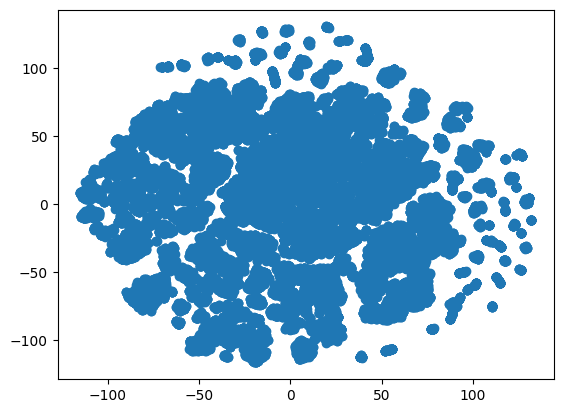

In [81]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1])

Text(0.5, 1.0, 'Std F1 Score')

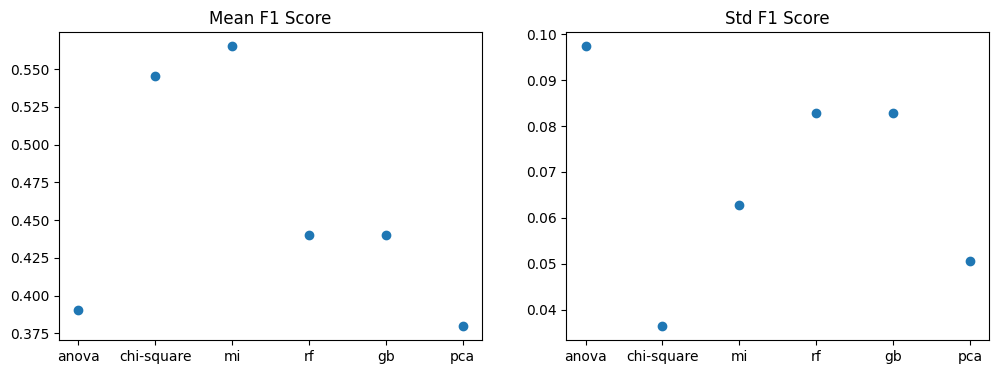

In [85]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

x, y = zip(*scores_mean.items())
ax[0].scatter(x, y)
ax[0].set_title("Mean F1 Score")

x, y = zip(*scores_std.items())
ax[1].scatter(x, y)
ax[1].set_title("Std F1 Score")

# Lưu dữ liệu tiền xử lý

In [83]:
df_process.to_csv(CSV_PROCESSED_PATH)